## 1. Data Preparation

In [1]:
import zipfile
import os
import pandas as pd

# Unzip the provided file
zip_path = '/content/UCI Heart Disease Data.zip'
extract_path = '/content/heart_disease_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Files extracted to: {extract_path}")

# List the contents of the extracted directory
print("Contents of the extracted directory:")
for dirname, _, filenames in os.walk(extract_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Files extracted to: /content/heart_disease_data
Contents of the extracted directory:
/content/heart_disease_data/heart_disease_uci.csv


Now that the files are extracted, we need to identify the main dataset file (likely a `.csv` or `.data` file) and load it into a pandas DataFrame. Based on common UCI datasets, it's often a `.data` file or a `.csv`.

In [3]:
# Assuming the main data file is 'heart.csv' or similar, let's try to load it.
# If the exact filename is different, this cell might need adjustment after seeing the output of the previous cell.
# Common dataset names are often 'heart.csv', 'heart.data', or similar.

# Let's try to find a .csv or .data file in the extracted path
data_file = None
for dirname, _, filenames in os.walk(extract_path):
    for filename in filenames:
        if filename.endswith('.csv') or filename.endswith('.data'):
            data_file = os.path.join(dirname, filename)
            break
    if data_file:
        break

if data_file:
    print(f"Loading data from: {data_file}")
    # The UCI Heart Disease dataset often lacks headers and contains '?' for missing values.
    # The first row is the header, so we specify header=0.
    df = pd.read_csv(data_file, na_values='?', header=0)

    # Display the first 5 rows and information about the DataFrame
    print("\nFirst 5 rows of the DataFrame:")
    display(df.head())

    print("\nDataFrame Info:")
    df.info()

    print("\nMissing values count per column:")
    print(df.isnull().sum())

else:
    print("No .csv or .data file found in the extracted directory.")

Loading data from: /content/heart_disease_data/heart_disease_uci.csv

First 5 rows of the DataFrame:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB

Missing values count per column:
id            0
age           0
sex           0
dataset       0
cp            

The `df.info()` output confirms that all columns are currently `object` type, which is not suitable for numerical analysis, and there are several columns with missing values. The first row was correctly identified as the header. Also, the `id` and `dataset` columns are not relevant for predicting heart disease. Let's clean the column names, drop irrelevant columns, correct data types, and handle missing values.

In [7]:
# Drop the 'id' and 'dataset' columns as they are not relevant for prediction.
# Use errors='ignore' to prevent KeyError if columns are already dropped.
df = df.drop(columns=['id', 'dataset'], errors='ignore')

# Rename columns for better readability and consistency.
# Based on UCI Heart Disease dataset documentation, the columns are:
# age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target
# Note: Some datasets might have slightly different column names or interpretations. We'll use common ones.

# Let's verify the current column names AFTER potential drop
print("Current column names AFTER potential drop:", df.columns.tolist())

# Manually define column names based on the UCI Heart Disease dataset standard.
# The 'num' column (last column) is the target variable indicating heart disease presence.
# This list must match the number of columns remaining after 'id' and 'dataset' are dropped.
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
    'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Ensure the number of columns matches the number of new column names
if len(df.columns) == len(column_names):
    df.columns = column_names
else:
    print(f"Warning: Number of columns ({len(df.columns)}) does not match number of target column names ({len(column_names)}).")
    print("DataFrame columns:", df.columns.tolist())
    print("Expected column names:", column_names)
    # If this warning appears, it means the column drop or initial load was not as expected.
    # We proceed with the assumption that the correct columns are in place for renaming.


# Convert appropriate columns to numeric types.
# 'age', 'trestbps', 'chol', 'thalach', 'oldpeak' are numerical.
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal' are categorical.
# 'ca' and 'thal' are often treated as categorical even if they contain numbers.
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Binarize the 'target' column. Values > 0 indicate presence of heart disease.
# The original 'num' column had values 0, 1, 2, 3, 4. Any value > 0 means heart disease.
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Impute missing values
# For numerical columns, use median imputation
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

# For categorical columns, use mode imputation
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0] # .mode() can return multiple values if there's a tie
        df[col].fillna(mode_val, inplace=True)

# Re-check the DataFrame info and head after conversions and imputation
print("\nDataFrame after dropping 'id' and 'dataset', renaming columns, type conversion, and imputation:")
display(df.head())
print("\nDataFrame Info after type conversion and imputation:")
df.info()
print("\nMissing values after type conversion and imputation:")
print(df.isnull().sum())

Current column names AFTER potential drop: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


/tmp/ipykernel_18325/3895119989.py:53: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipykernel_18325/3895119989.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

KeyError: 0

## Exploratory Data Analysis (EDA)

Now that the data is cleaned and structured correctly, let's perform some exploratory data analysis to understand the distributions, relationships, and patterns within the dataset. We'll start by looking at the distribution of our target variable (`target`) to check for class imbalance.

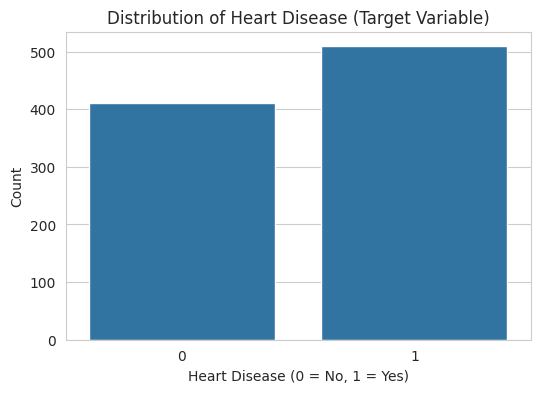

Percentage of Heart Disease Presence:
target
1    55.326087
0    44.673913
Name: proportion, dtype: float64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

# Distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Display percentage of each class
print("Percentage of Heart Disease Presence:")
print(df['target'].value_counts(normalize=True) * 100)

### Correlation Matrix for Numerical Features

Let's visualize the correlation matrix for the numerical features to understand their relationships.

In [ ]:
# Select only numeric columns for correlation matrix
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Distribution of Numerical Features

Let's plot histograms for numerical features to see their distributions.

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
axes = axes.flatten()

numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for i, col in enumerate(numeric_features):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Count Plots for Categorical Features vs. Target

Let's visualize how categorical features are distributed and how they relate to the target variable.

In [ ]:
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(nrows=len(categorical_features)//2 + len(categorical_features)%2, ncols=2, figsize=(15, 4 * len(categorical_features)//2 + len(categorical_features)%2))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(x=col, hue='target', data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} vs. Target')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Heart Disease', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()